# Lab 1: MLP Regression & Classification

**Name:** *(Noah Reed and Jack Nelson)*

Part 1 continues directly from what you already built — same dataset, same one-hot encoding approach, a regression MLP. Parts 2 and 3 apply that same MLP-building pattern to a new problem type: classification instead of regression. Watch closely for exactly which pieces of the code change, and which stay identical.

## Setup — Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Shared helper: plotting loss (and accuracy, when available)

We'll reuse this for all three parts so the curves are directly comparable.

In [10]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
# Part 1 — Regression with One-Hot Encoding (Ames Housing)

In [11]:
ames = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = ames.frame
df = df[["GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF", "GarageCars",
        "Neighborhood", "HouseStyle", "MSZoning", "SalePrice"]].dropna()

categorical_features = ["Neighborhood", "HouseStyle", "MSZoning"]

# One-hot encode
df_onehot = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Spilt the data into Features and Target Variables
X1 = df_onehot.drop(columns=["SalePrice"]).values.astype(float)
y1 = df_onehot["SalePrice"].values.astype(float)

# Print the shape of feature matrix
print("Feature matrix shape:", X1.shape)

Feature matrix shape: (1460, 40)


In [12]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

x1_scaler = StandardScaler()
X1_train_scaled = x1_scaler.fit_transform(X1_train)
X1_test_scaled = x1_scaler.transform(X1_test)

y1_scaler = StandardScaler()
y1_train_scaled = y1_scaler.fit_transform(y1_train.reshape(-1, 1)).flatten()
y1_test_scaled = y1_scaler.transform(y1_test.reshape(-1, 1)).flatten()

**Build your MLP.** Fill in the blanks (`___`) and be ready to justify your choices.

In [13]:
model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X1_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Q: Why does the output layer have no activation function?
# Your answer: When you are using a regression model, the output layer does not need a activation function, only for classification does the output layer need an activation function.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


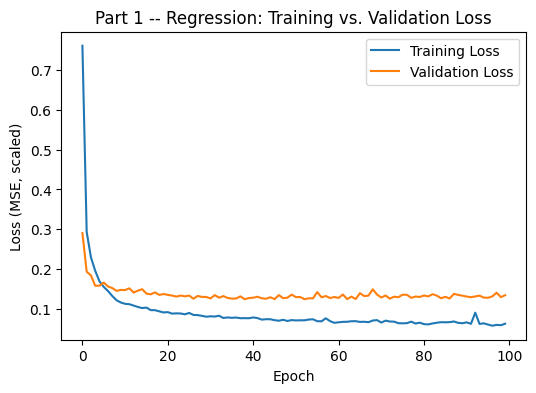

In [14]:
history_reg = model_reg.fit(
    X1_train_scaled, y1_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_reg, "Part 1 -- Regression: Training vs. Validation Loss")

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* This is a good fit, because the training and validation loss are steadily going downwards. They are also under the 0.2 Loss metric which is a good indicator for a good fit.


In [15]:
preds_scaled = model_reg.predict(X1_test_scaled).flatten()
preds_dollars = y1_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

rmse_reg = np.sqrt(np.mean((preds_dollars - y1_test) ** 2))
mae_reg = np.mean(np.abs(preds_dollars - y1_test))

print(f"Part 1 -- Test RMSE: ${rmse_reg:,.0f}")
print(f"Part 1 -- Test MAE:  ${mae_reg:,.0f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Part 1 -- Test RMSE: $32,640
Part 1 -- Test MAE:  $20,296


---
# Part 2 — Binary Classification (Pima Indians Diabetes)

Predicting whether a patient has diabetes (1) or not (0) from 8 medical measurements.

In [16]:
diabetes = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")
df2 = diabetes.frame

print(df2.shape)
print(df2["class"].value_counts())

# Q: How many classes? Is this dataset balanced or imbalanced?
# Your answer: 768, this is an imbalanced dataset because there are almost double the amount of people who tested negative vs. positive.


(768, 9)
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64


In [17]:
X2 = df2.drop(columns=["class"]).values.astype(float)
y2 = (df2["class"] == "tested_positive").astype(int).values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Q: Why stratify here? Why did Part 1 not need this?
# Your answer: Stratification is used because class is categorical and since it is an imbalanced dataset we need to stratify the split to ensure that both training and testing split have the same proportion. Stratification is used for classification so part 1 did not need this.

x2_scaler = StandardScaler()
X2_train_scaled = x2_scaler.fit_transform(X2_train)
X2_test_scaled = x2_scaler.transform(X2_test)

# Note: y2 is NOT scaled here.
# Q: Why not, compared to Part 1's y1_scaler?
# Your answer: There is no benefit of scaling a binary classification problem because it would just distort the meaning and not provide any advantage to the model.


**Build your MLP.** Fill in the blanks — this time there are two new ones: the output activation, and the loss function.

In [20]:
# Create the classification model
model_binary = tf.keras.Sequential([tf.keras.layers.Dense(64, activation="relu", input_shape=(X2_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_binary.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Q: What output activation did you use, and why does it fit a yes/no prediction?
# Your answer: We used a sigmoid for the output activation function because this is a binary classification so the sigmoid puts the numler into 0-1.

# Q: What loss function did you use, and how does it relate to what "sigmoid" outputs?
# Your answer: I used binary_crossentropy as the loss function. This loss function is good for binary classification tasks where the output layer uses a sigmoid activation function because it measures the performance of a classification model whose output is a probability value between 0 and 1

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


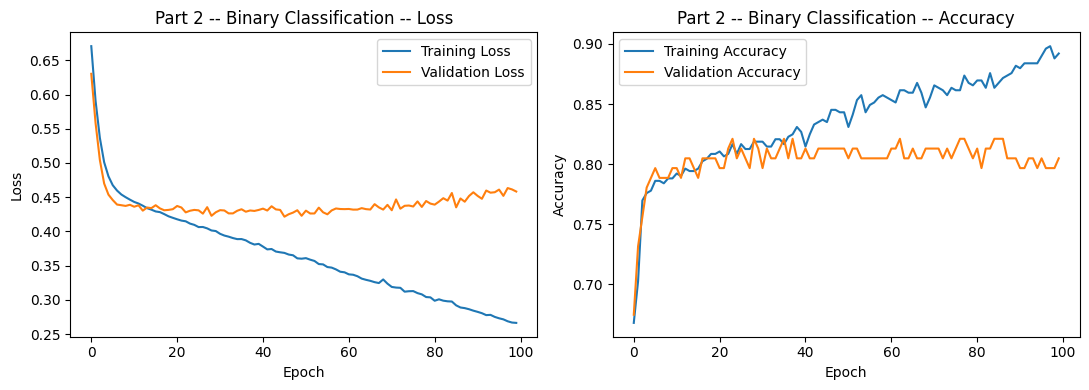

In [21]:
history_binary = model_binary.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_binary, "Part 2 -- Binary Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* Overfitting, because our training loss keeps going down, while the validation loss starts to go up after some epochs.





5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Part 2 -- Test Accuracy: 0.753


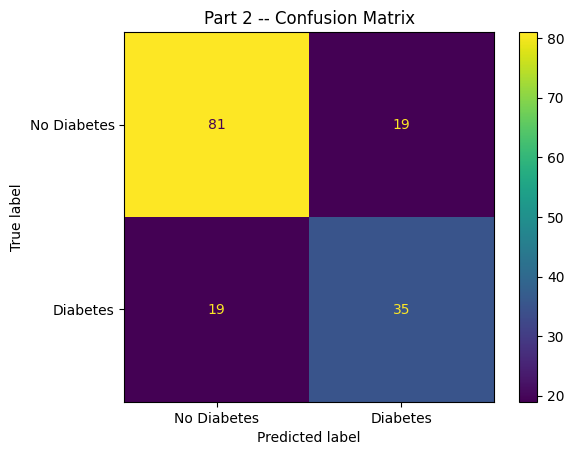

In [22]:
binary_preds = (model_binary.predict(X2_test_scaled).flatten() >= 0.5).astype(int)

acc_binary = accuracy_score(y2_test, binary_preds)
print(f"Part 2 -- Test Accuracy: {acc_binary:.3f}")

cm = confusion_matrix(y2_test, binary_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot()
plt.title("Part 2 -- Confusion Matrix")
plt.show()

# Q: In a medical diagnosis context, are false positives and false negatives
# equally costly? Which would you rather minimize, and why? How might that
# change the 0.5 threshold you'd choose?
# Your answer: False negtive is a greater cost, A false negative is worse, because you would miss something that could be fatal where a false positive means you think something bad is happening when its not. I would rather minimize the false negatives.
# Lowering the threshold would make the model more sensitive to detecting actual cases of diabetes, which reduces false negtives, but also will likely increaase the number of false positives.


---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [23]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [24]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer: 3 classes, and 0,1 are reasonably balanced but class 2 is much lower than the other two.


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [25]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [32]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([tf.keras.layers.Dense(128, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers:3 output neurons, 1 for each class. sparsecategorical_crossentropy

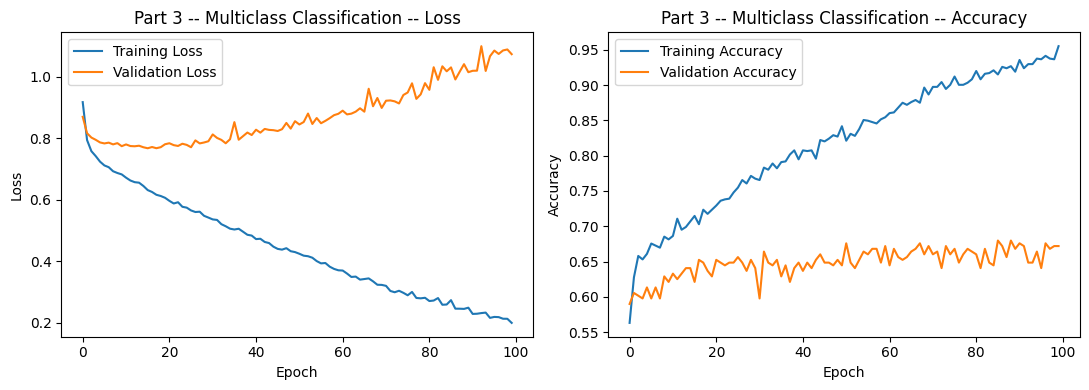

In [33]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* This is overfitting because the training loss is decreasing while the validation loss is increasing.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.709


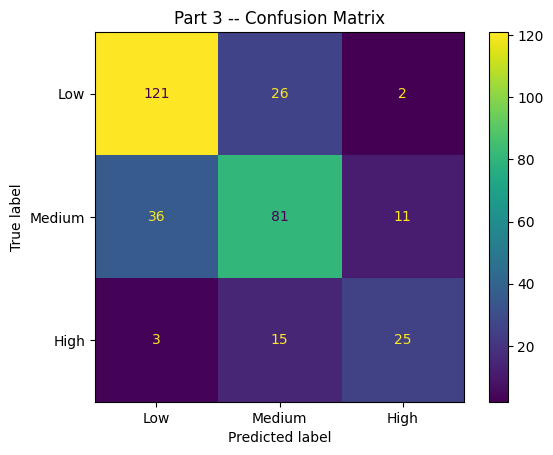

In [34]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer: The model struggles at properly identifying high as shown by the confusion matrix where the bottom right square is not as high as hts respective classes in the middle square and upper left.


---
# Comparison & Reflection

Fill in from your own three models:

| | Part 1 (Regression) | Part 2 (Binary) | Part 3 (Multiclass) |
|---|---|---|---|
| Output neurons |1 |1 |3 |
| Output activation |none |sigmoid |softmax |
| Loss function |mse |binary_crossentropy |sparse_categorical_crossentropy |
| Label format |regression |classification |multiclass classification |
| Evaluation metric(s) |mae |accuracy |accuracy |

**Write 4–5 sentences:**

1. What's the general rule connecting the *number of classes* to the *number of output neurons* and the *choice of activation*? if there are more than two classes then the number of neurons is = to number of classes. If there are two classes 0 or 1 then its a sigmoid, and if there are more than two then it uses a softmax activation function.
2. Why doesn't regression need an activation function on the output, while both classification tasks do? Because regression predicts continuous numerical values so an activation function would tr to squeeze this output into a specific range such as 0-1 for sigmoid which is not suitable for predicting continuous values.
3. For Part 3: why might accuracy alone be a misleading metric if your class counts are imbalanced? If the model is imbalanced then a model can achieve a high oveall accuracy by predicting the majority of the class most of the time even if its performing poorly on the minority classes.

*Your answer:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.